In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

INFILE = Path("Input/PUL_undil_HIP245_02_17_26.tsv")

df = pd.read_csv(INFILE, sep="\t")

print("Shape:", df.shape)
df.head()

Shape: (8, 11)


,Unnamed: 0,ERG11,GPA1,HSE1,NEM1,STP2,YPT31,RIB4,NOP8,TDA3,MET5
0,PUL -,0.597,0.108,0.589,0.849,0.833,0.443,0.655,0.781,0.551,0.587
1,PUL -,0.468,0.110,0.551,0.642,0.800,0.356,0.621,0.489,0.468,0.482
2,PUL -,0.718,0.116,0.559,0.813,0.755,0.492,0.607,0.605,0.348,0.644
3,PUL -,0.697,0.117,0.648,0.820,0.778,0.390,0.735,0.623,0.510,0.091
4,PUL +,0.123,0.095,0.259,0.475,0.431,0.119,0.336,0.457,0.314,0.654


In [25]:
# First column contains condition labels
COND_COL = df.columns[0]

df_plus  = df[df[COND_COL] == "PUL +"].copy()
df_minus = df[df[COND_COL] == "PUL -"].copy()

print("PUL+ rows:", df_plus.shape[0])
print("PUL- rows:", df_minus.shape[0])

PUL+ rows: 4
PUL- rows: 4


In [26]:
# Gene columns = everything except condition column
gene_cols = df.columns[1:]

# Convert to numeric to be safe
df_plus[gene_cols]  = df_plus[gene_cols].apply(pd.to_numeric, errors="coerce")
df_minus[gene_cols] = df_minus[gene_cols].apply(pd.to_numeric, errors="coerce")

# Mean across replicates
mean_plus  = df_plus[gene_cols].mean()
mean_minus = df_minus[gene_cols].mean()

mean_plus.head()

ERG11    0.11975
GPA1     0.09675
HSE1     0.37225
NEM1     0.44275
STP2     0.46775
dtype: float64

In [27]:
PSEUDOCOUNT = 0  # change to 1 if zeros are possible

FD = np.log10((mean_plus + PSEUDOCOUNT) / (mean_minus + PSEUDOCOUNT))

fd_df = pd.DataFrame({
    "Gene": gene_cols,
    "Mean_PUL_plus": mean_plus.values,
    "Mean_PUL_minus": mean_minus.values,
    "FD_score": FD.values
})

fd_df = fd_df.sort_values("FD_score")

fd_df

,Gene,Mean_PUL_plus,Mean_PUL_minus,FD_score
0,ERG11,0.11975,0.62000,-0.714116
5,YPT31,0.18175,0.42025,-0.364033
6,RIB4,0.28575,0.65450,-0.359923
3,NEM1,0.44275,0.78100,-0.246492
4,STP2,0.46775,0.79150,-0.228437
8,TDA3,0.28600,0.46925,-0.215038
2,HSE1,0.37225,0.58675,-0.197618
7,NOP8,0.52400,0.62450,-0.076201
1,GPA1,0.09675,0.11275,-0.066466
9,MET5,0.46625,0.45100,0.014442


In [28]:
OUTFILE = Path("Output/PUL_1X_YPD_scores.tsv")
fd_df.to_csv(OUTFILE, sep="\t", index=False)

print("Saved:", OUTFILE)

Saved: Output/PUL_1X_YPD_scores.tsv


In [29]:
# Safety check: same number of replicates
if df_plus.shape[0] != df_minus.shape[0]:
    raise ValueError(
        f"Mismatch in replicate counts: "
        f"{df_plus.shape[0]} PUL+ vs {df_minus.shape[0]} PUL-"
    )

n_reps = df_plus.shape[0]
print("Number of replicate pairs:", n_reps)

PSEUDOCOUNT = 0  # set to 1 if zeros possible

# Store per-replicate FD values
fd_rep_list = []

for i in range(n_reps):
    plus_vals  = df_plus.iloc[i][gene_cols].astype(float)
    minus_vals = df_minus.iloc[i][gene_cols].astype(float)

    fd_rep = np.log10((plus_vals + PSEUDOCOUNT) /
                      (minus_vals + PSEUDOCOUNT))

    fd_rep_list.append(fd_rep)

# Convert to DataFrame
fd_rep_df = pd.DataFrame(fd_rep_list)
fd_rep_df.columns = gene_cols
fd_rep_df.index = [f"Rep_{i+1}" for i in range(n_reps)]

fd_rep_df

Number of replicate pairs: 4


,ERG11,GPA1,HSE1,NEM1,STP2,YPT31,RIB4,NOP8,TDA3,MET5
Rep_1,-0.686069,-0.055700,-0.356816,-0.252214,-0.286168,-0.570857,-0.289902,-0.232735,-0.244222,0.046940
Rep_2,-0.569875,-0.050167,0.155375,-0.094885,-0.163518,-0.039567,-0.347487,0.157028,-0.197489,-0.113673
Rep_3,-0.769765,-0.082187,-0.546015,-0.281702,-0.237466,-0.464078,-0.273986,-0.096014,-0.201135,-0.206826
Rep_4,-0.809809,-0.076960,-0.359789,-0.363585,-0.233924,-0.534160,-0.554533,-0.139350,-0.210641,0.684411


In [30]:
OUTFILE_REP = Path("Output/PUL_1X_YPD_per_replicate.tsv")
fd_rep_df.to_csv(OUTFILE_REP, sep="\t")

print("Saved:", OUTFILE_REP)

Saved: Output/PUL_1X_YPD_per_replicate.tsv


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose error bar type: "sd" or "sem"
ERROR_BARS = "sd"   # change to "sem" if you prefer SEM

fd_mean = fd_rep_df.mean(axis=0)
fd_sd   = fd_rep_df.std(axis=0, ddof=1)
fd_sem  = fd_sd / np.sqrt(fd_rep_df.shape[0])

summary = pd.DataFrame({
    "Gene": fd_rep_df.columns,
    "FD_mean": fd_mean.values,
    "FD_sd": fd_sd.values,
    "FD_sem": fd_sem.values
}).sort_values("FD_mean").reset_index(drop=True)

summary

,Gene,FD_mean,FD_sd,FD_sem
0,ERG11,-0.708880,0.106044,0.053022
1,YPT31,-0.402165,0.245758,0.122879
2,RIB4,-0.366477,0.129285,0.064643
3,HSE1,-0.276811,0.301408,0.150704
4,NEM1,-0.248097,0.112484,0.056242
5,STP2,-0.230269,0.050483,0.025241
6,TDA3,-0.213372,0.021301,0.010650
7,NOP8,-0.077767,0.166603,0.083301
8,GPA1,-0.066253,0.015691,0.007846
9,MET5,0.102713,0.401713,0.200857


In [32]:
import matplotlib as mpl

mpl.rcParams.update({

    # Font sizes
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,

    # Make axis labels bold
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",

    # Thicker axes lines
    "axes.linewidth": 1.5,

    # Thicker ticks
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,

})

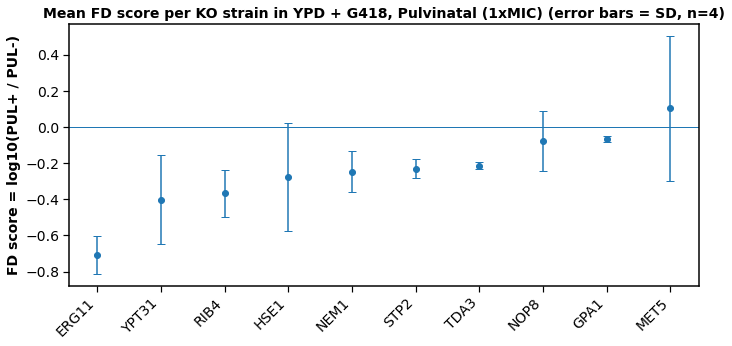

In [33]:
yerr = summary["FD_sd"].to_numpy() if ERROR_BARS == "sd" else summary["FD_sem"].to_numpy()

x = np.arange(summary.shape[0])

plt.figure(figsize=(max(10, 0.8 * len(summary)), 5))
plt.errorbar(
    x,
    summary["FD_mean"].to_numpy(),
    yerr=yerr,
    fmt="o",
    capsize=4
)

plt.axhline(0, linewidth=1)
plt.xticks(x, summary["Gene"].tolist(), rotation=45, ha="right")
plt.ylabel("FD score = log10(PUL+ / PUL-)")
plt.title(f"Mean FD score per KO strain in YPD + G418, Pulvinatal (1xMIC) (error bars = {ERROR_BARS.upper()}, n={fd_rep_df.shape[0]})")
plt.tight_layout()
plt.show()

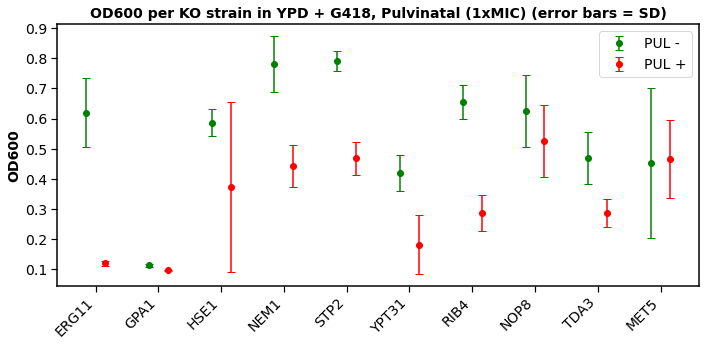

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Error bar type: "sd" or "sem"
ERROR_BARS = "sd"

COND_COL = df.columns[0]
gene_cols = df.columns[1:]

# Split conditions
df_minus = df[df[COND_COL] == "PUL -"].copy()
df_plus  = df[df[COND_COL] == "PUL +"].copy()

# Ensure numeric
df_minus[gene_cols] = df_minus[gene_cols].apply(pd.to_numeric, errors="coerce")
df_plus[gene_cols]  = df_plus[gene_cols].apply(pd.to_numeric, errors="coerce")

# Compute means
mean_minus = df_minus[gene_cols].mean()
mean_plus  = df_plus[gene_cols].mean()

# Compute variability
sd_minus = df_minus[gene_cols].std(ddof=1)
sd_plus  = df_plus[gene_cols].std(ddof=1)

sem_minus = sd_minus / np.sqrt(df_minus.shape[0])
sem_plus  = sd_plus  / np.sqrt(df_plus.shape[0])

err_minus = sd_minus if ERROR_BARS == "sd" else sem_minus
err_plus  = sd_plus  if ERROR_BARS == "sd" else sem_plus

# X positions
x = np.arange(len(gene_cols))
offset = 0.15  # small horizontal shift

plt.figure(figsize=(max(10, 0.8 * len(gene_cols)), 5))

# Plot PUL -
plt.errorbar(
    x - offset,
    mean_minus.values,
    yerr=err_minus.values,
    fmt="o",
    capsize=4,
    color="green",
    ecolor="green",
    label="PUL -"
)

# Plot PUL +
plt.errorbar(
    x + offset,
    mean_plus.values,
    yerr=err_plus.values,
    fmt="o",
    capsize=4,
    color="red",
    ecolor="red",
    label="PUL +"
)

plt.xticks(x, gene_cols, rotation=45, ha="right")
plt.ylabel("OD600")
plt.title(f"OD600 per KO strain in YPD + G418, Pulvinatal (1xMIC) (error bars = {ERROR_BARS.upper()})")
plt.legend()
plt.tight_layout()
plt.show()